In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
model_results = pd.read_csv(
    "../model/model_comparison.csv"
)

tuned_results = pd.read_csv(
    "../model/tuned_xgb_results.csv"
)

final_results = pd.concat(
    [model_results, tuned_results],
    ignore_index=True
)

final_results.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
3,XGBoost,530.975835,3902.367071,0.967192
4,Tuned XGBoost,5911.768552,13870.593023,0.585512
2,Random Forest (Top 20 Features),6117.023600,14434.001300,0.551156
1,Random Forest (All Features),6063.720405,14474.880927,0.548610
0,Linear Regression,8186.066088,16362.694503,0.423191


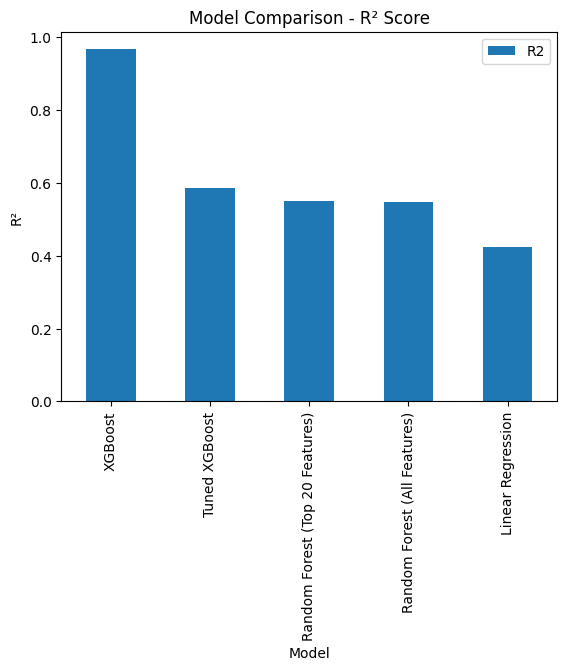

In [4]:
final_results.sort_values(
    by='R2',
    ascending=False
).plot(
    x='Model',
    y='R2',
    kind='bar'
)

plt.title('Model Comparison - R² Score')
plt.ylabel('R²')
plt.show()

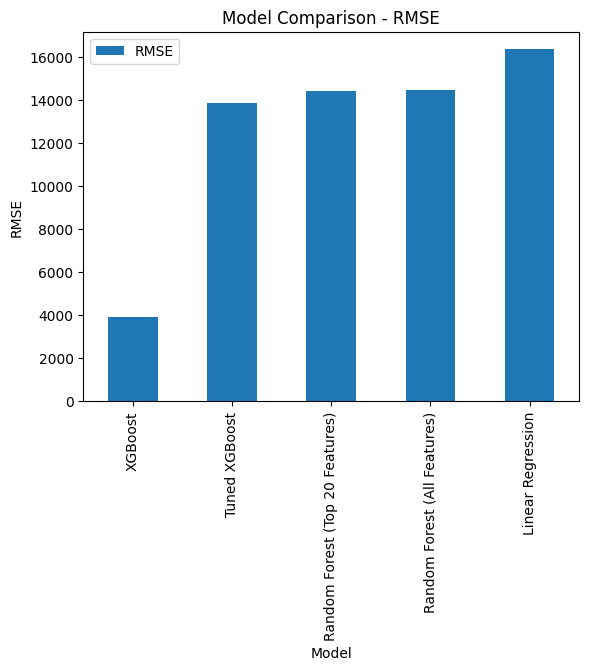

In [5]:
final_results.sort_values(
    by='RMSE'
).plot(
    x='Model',
    y='RMSE',
    kind='bar'
)

plt.title('Model Comparison - RMSE')
plt.ylabel('RMSE')
plt.show()

In [7]:
df = pd.read_csv(
    "../data/processed/campaign_data_feature_engineered.csv"
)

In [8]:
drop_cols = [
    'revenue',
    'profit',
    'revenue_per_click',
    'revenue_per_conversion',
    'profit_margin'
]

df = df.drop(columns=drop_cols)

In [9]:
X = df.drop('roi', axis=1)
y = df['roi']

In [10]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [16]:
import joblib

selected_features = joblib.load(
    "../model/model_features.pkl"
)

X = X[selected_features]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [19]:
y_pred = best_model.predict(X_test)

NameError: name 'best_model' is not defined